# Model Comparison: CNN10 vs CNN12, with/without Synthetic Data
## Compare 8 configurations across 2 test sets (13b and 14a).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, roc_auc_score, confusion_matrix
)

## 1. Load all result CSVs
Each CSV should have columns: `prob_neg`, `prob_pos`, `y_true`

In [2]:
experiments = {
    "CNN10 + synth / 13b":   "../with_synth_results/13b_cnn10eval_file_probs.csv",
    "CNN10 + synth / 14a":   "../with_synth_results/14a_cnn10eval_file_probs.csv",
    "CNN10 no synth / 13b":  "../without_synth_results/13b_cnn10eval_file_probs.csv",
    "CNN10 no synth / 14a":  "../without_synth_results/14a_cnn10eval_file_probs.csv",
    "CNN12 + synth / 13b":   "../with_synth_results/13b_cnn12eval_file_probs.csv",
    "CNN12 + synth / 14a":   "../with_synth_results/14a_cnn12eval_file_probs.csv",
    "CNN12 no synth / 13b":  "../without_synth_results/13b_cnn12eval_file_probs.csv",
    "CNN12 no synth / 14a":  "../without_synth_results/14a_cnn12eval_file_probs.csv",
}

In [3]:
THRESHOLD = 0.5

results = []
raw_data = {}

for name, path in experiments.items():
    df = pd.read_csv(path)
    prob_pos = df["prob_pos"].values
    y_true = df["y_true"].values
    preds = (prob_pos >= THRESHOLD).astype(int)

    # parse experiment name
    parts = name.split(" / ")
    config = parts[0]
    test_set = parts[1]
    model = "CNN10" if "CNN10" in config else "CNN12"
    synthetic = "Yes" if "+ synth" in config else "No"

    row = {
        "experiment": name,
        "model": model,
        "synthetic": synthetic,
        "test_set": test_set,
        "n_files": len(df),
        "n_positive": int((y_true == 1).sum()),
        "n_negative": int((y_true == 0).sum()),
        "precision": precision_score(y_true, preds, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, preds, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, preds, pos_label=1, zero_division=0),
        "precision-macro": precision_score(y_true, preds, pos_label=1, zero_division=0, average="macro"),
        "recall-macro": recall_score(y_true, preds, pos_label=1, zero_division=0, average="macro"),
        "f1-macro": f1_score(y_true, preds, pos_label=1, zero_division=0, average="macro"),
        "accuracy": accuracy_score(y_true, preds),
        "auc": roc_auc_score(y_true, prob_pos) if len(np.unique(y_true)) > 1 else np.nan,
    }


    results.append(row)
    raw_data[name] = {"prob_pos": prob_pos, "y_true": y_true}

results_df = pd.DataFrame(results)
print(f"Loaded {len(results)} experiments")

Loaded 8 experiments


## 2. Summary Table

In [4]:
display_cols = [
    "model", "synthetic", "test_set",
    "f1", "precision", "recall",
    "f1-macro", "precision-macro", "recall-macro",
    "auc",
   # "best_f1", "best_threshold"
]
summary = results_df[display_cols].sort_values(
    ["test_set", "f1"], ascending=[True, False]
)
print(summary.to_string(index=False, float_format="%.4f"))

model synthetic test_set     f1  precision  recall  f1-macro  precision-macro  recall-macro    auc
CNN10        No      13b 0.7250     0.7436  0.7073    0.8582           0.8671        0.8497 0.9927
CNN12        No      13b 0.7250     0.7436  0.7073    0.8582           0.8671        0.8497 0.9901
CNN10       Yes      13b 0.7071     0.6034  0.8537    0.8478           0.7993        0.9178 0.9911
CNN12       Yes      13b 0.6829     0.6829  0.6829    0.8364           0.8364        0.8364 0.9905
CNN12       Yes      14a 0.7059     0.6667  0.7500    0.8516           0.8323        0.8734 0.9917
CNN10       Yes      14a 0.6667     0.5385  0.8750    0.8315           0.7687        0.9344 0.9948
CNN10        No      14a 0.6667     0.7143  0.6250    0.8320           0.8556        0.8115 0.9948
CNN12        No      14a 0.6667     0.7143  0.6250    0.8320           0.8556        0.8115 0.9969


## 3. Precision vs Recall Scatter

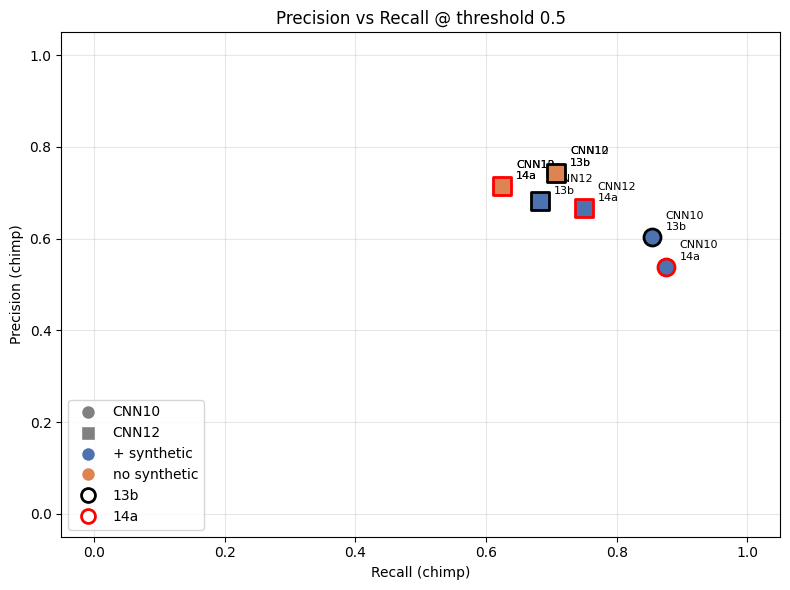

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

markers = {"CNN10": "o", "CNN12": "s"}
colors = {"Yes": "#4C72B0", "No": "#DD8452"}
edge_colors = {"13b": "black", "14a": "red"}

for _, row in results_df.iterrows():
    ax.scatter(
        row["recall"], row["precision"],
        marker=markers[row["model"]],
        c=colors[row["synthetic"]],
        edgecolors=edge_colors[row["test_set"]],
        s=150, linewidths=2, zorder=5
    )
    ax.annotate(
        f"{row['model']}\n{row['test_set']}",
        (row["recall"], row["precision"]),
        textcoords="offset points",
        xytext=(10, 5), fontsize=8
    )

legend_elements = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="gray", markersize=10, label="CNN10"),
    Line2D([0], [0], marker="s", color="w",
           markerfacecolor="gray", markersize=10, label="CNN12"),
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="#4C72B0", markersize=10, label="+ synthetic"),
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="#DD8452", markersize=10, label="no synthetic"),
    Line2D([0], [0], marker="o", color="w",
           markeredgecolor="black", markersize=10,
           markeredgewidth=2, label="13b"),
    Line2D([0], [0], marker="o", color="w",
           markeredgecolor="red", markersize=10,
           markeredgewidth=2, label="14a"),
]
ax.legend(handles=legend_elements, loc="lower left")
ax.set_xlabel("Recall (chimp)")
ax.set_ylabel("Precision (chimp)")
ax.set_title("Precision vs Recall @ threshold 0.5")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Score Distributions

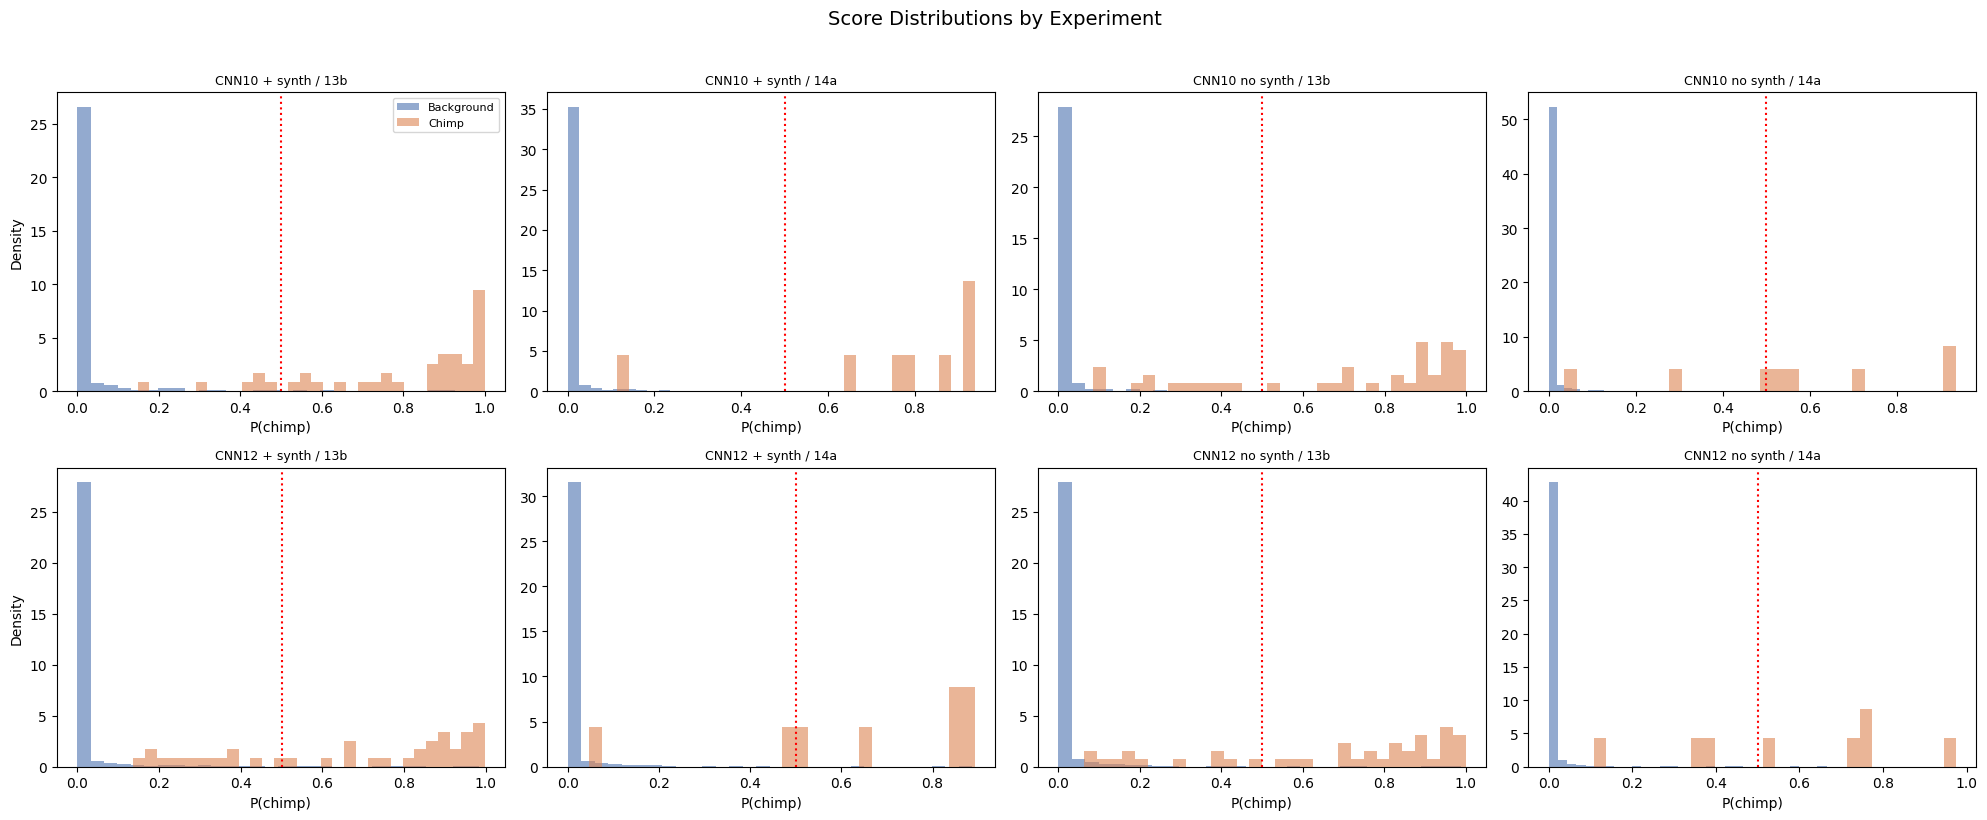

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for idx, (name, data) in enumerate(raw_data.items()):
    row = idx // 4
    col = idx % 4
    ax = axes[row][col]

    prob_pos = data["prob_pos"]
    y_true = data["y_true"]

    ax.hist(
        prob_pos[y_true == 0], bins=30, alpha=0.6,
        label="Background", density=True, color="#4C72B0"
    )
    ax.hist(
        prob_pos[y_true == 1], bins=30, alpha=0.6,
        label="Chimp", density=True, color="#DD8452"
    )
    ax.axvline(0.5, color="red", linestyle=":", linewidth=1.5)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("P(chimp)")
    if col == 0:
        ax.set_ylabel("Density")
    if idx == 0:
        ax.legend(fontsize=8)

plt.suptitle("Score Distributions by Experiment", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Confusion Matrices

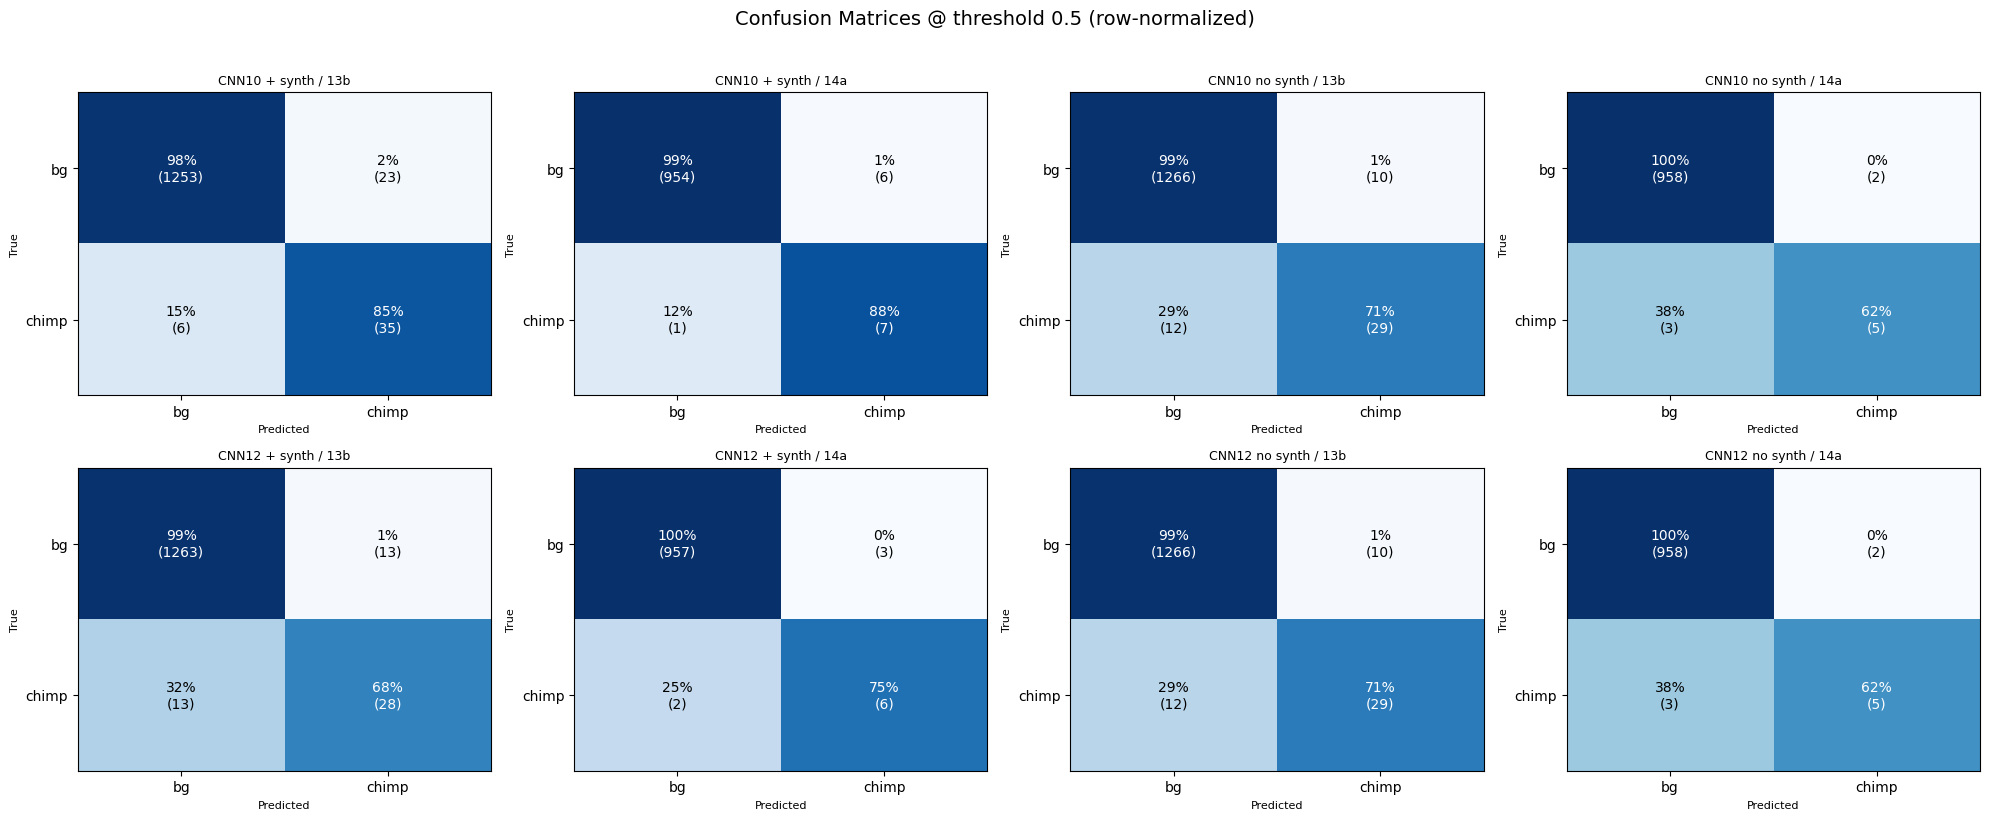

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for idx, (name, data) in enumerate(raw_data.items()):
    row = idx // 4
    col = idx % 4
    ax = axes[row][col]
    prob_pos = data["prob_pos"]
    y_true = data["y_true"]
    preds = (prob_pos >= THRESHOLD).astype(int)
    cm = confusion_matrix(y_true, preds)

    # Normalize by row (true label) → each row sums to 1
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap="Blues", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["bg", "chimp"])
    ax.set_yticklabels(["bg", "chimp"])
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)
    ax.set_title(name, fontsize=9)

    for i in range(2):
        for j in range(2):
            val = cm_norm[i, j]
            raw = cm[i, j]
            color = "white" if val > 0.5 else "black"
            ax.text(
                j, i, f"{val:.0%}\n({raw})",
                ha="center", va="center",
                color=color, fontsize=10
            )

plt.suptitle("Confusion Matrices @ threshold 0.5 (row-normalized)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Conclusion

We evalute the models based on the macro average recall. As it can be seen in the results, CNN10 model which is trained on original+synthetic data has the best results